# REDES NEURONALES

---



En esta actividad vamos a utilizar una red neuronal para clasificar imágenes de dígitos del 0 al 9 escritos a mano. Para ello, utilizaremos Keras con TensorFlow.

El dataset a utilizar es MNIST, una base de datos constituida por (como no) imágenes de dígitos escritos a mano. Este dataset es ampliamente utilizado en docencia como punto de entrada al entrenamiento de redes neuronales y otros, pero también es muy utilizado en trabajos reales de investigación para el entrenamiento de imágenes. Puedes consultar más información sobre el dataset en [este enlace](https://es.wikipedia.org/wiki/Base_de_datos_MNIST).

El código utilizado para contestar tiene que quedar claramente reflejado en el Notebook. Puedes crear nuevas celdas si así lo deseas para estructurar tu código y sus salidas. A la hora de entregar el notebook, **asegúrate de que los resultados de ejecutar tu código han quedado guardados y que son perfectamente visibles en la versión PDF que debes entregar adjunta**. Por ejemplo, a la hora de entrenar una red neuronal tiene que verse claramente un log de los resultados de cada epoch.

In [ ]:
from keras.datasets.mnist import load_data
import tensorflow as tf
import matplotlib.pyplot as plt

Tenemos la suerte de que el dataset MNIST, el que vamos a utilizar en esta actividad, está guardado en Keras, por lo que podemos utilizarlo sin necesidad de buscar el dataset de forma externa.

In [ ]:
mnist = tf.keras.datasets.fashion_mnist

Llamar a **load_data** en este dataset nos dará dos conjuntos de dos listas, estos serán los valores de entrenamiento y prueba para los gráficos que contienen los dígitos y sus etiquetas.

Nota: Aunque en esta actividad lo veis de esta forma, también lo vais a poder encontrar como 4 variables de esta forma: training_images, training_labels, test_images, test_labels = mnist.load_data()

In [ ]:
(training_images, training_labels), (test_images, test_labels) = load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Antes de continuar vamos a dar un vistazo a nuestro dataset, para ello vamos a ver una imagen de entrenamiento y su etiqueta o clase.

5
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136 175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253 225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251  93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0   0  18 219 253 253 253 253 253 198 182 247 241   0 

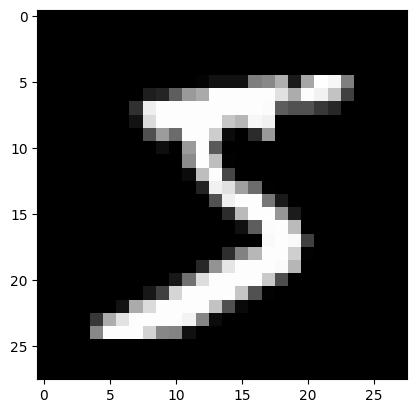

In [ ]:
import numpy as np
np.set_printoptions(linewidth=200)
plt.imshow(training_images[0], cmap="gray") # recordad que siempre es preferible trabajar en blanco y negro
#
print(training_labels[0])
print(training_images[0])

## 1. Información sobre el dataset

Una vez tenemos los datos cargados en memoria, vamos a obtener información sobre los mismos.

**Pregunta 1.1 *(0.25 puntos)*** ¿Cuántas imágenes hay de *training* y de *test*? ¿Qué tamaño tienen las imágenes?

In [ ]:
from keras.datasets.mnist import load_data

# Cargar MNIST
(training_images, training_labels), (test_images, test_labels) = load_data()

# Mostrar tamaños y formas
print("Training images shape:", training_images.shape)
print("Training labels shape:", training_labels.shape)
print("Test images shape:", test_images.shape)
print("Test labels shape:", test_labels.shape)

# Tamaño de cada imagen
h, w = training_images.shape[1], training_images.shape[2]
print(f"Tamaño de cada imagen: {h} x {w} (pixeles, 1 canal/grayscale)")

Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Test images shape: (10000, 28, 28)
Test labels shape: (10000,)
Tamaño de cada imagen: 28 x 28 (pixeles, 1 canal/grayscale)


*Existen 60000 imágenes de training y 10000 de test. Cada una de esas imagenes tiene un tamaño de 28 × 28 píxeles, todas en escala de grises.*

**Pregunta 1.2 *(0.25 puntos)*** Realizar una exploración de las variables que contienen los datos. Describir en qué consiste un example del dataset (qué información se guarda en cada imagen) y describir qué contiene la información en y.

=== TRAINING ===
X shape: (60000, 28, 28) | dtype: uint8
y shape: (60000,) | dtype: uint8
Pixel stats -> min: 0 max: 255 mean: 33.32 std: 78.57
Label set: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Label distribution (counts): {0: 5923, 1: 6742, 2: 5958, 3: 6131, 4: 5842, 5: 5421, 6: 5918, 7: 6265, 8: 5851, 9: 5949}

=== TEST ===
X shape: (10000, 28, 28) | dtype: uint8
y shape: (10000,) | dtype: uint8
Pixel stats -> min: 0 max: 255 mean: 33.79 std: 79.17
Label set: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Label distribution (counts): {0: 980, 1: 1135, 2: 1032, 3: 1010, 4: 982, 5: 892, 6: 958, 7: 1028, 8: 974, 9: 1009}

=== EXAMPLE ===
Index: 0
Image shape: (28, 28) | dtype: uint8
Image pixel stats -> min: 0 max: 255 mean: 35.11 std: 79.65
Label: 5


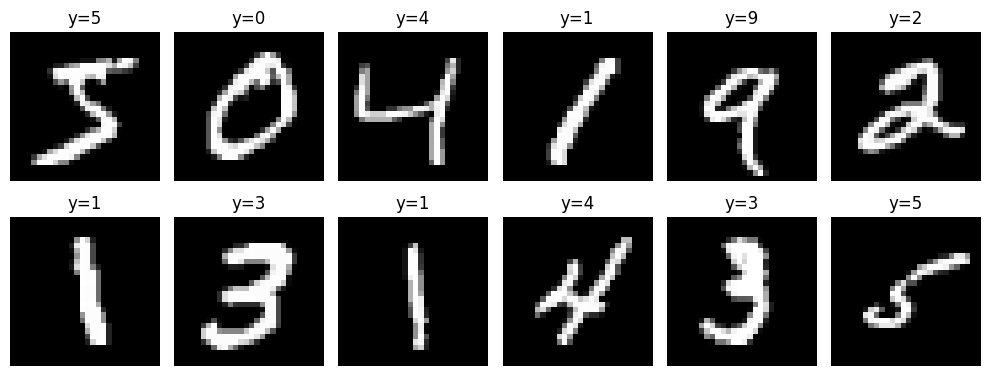

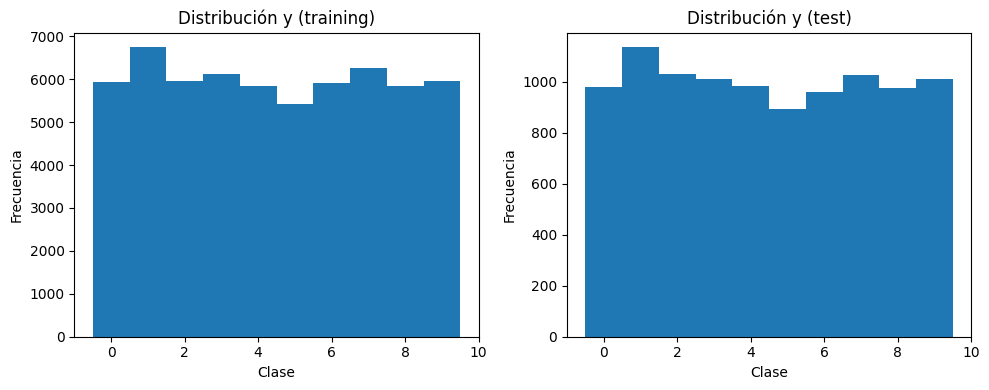

In [ ]:
def describe_split(X, y, name="split"):
    print(f"=== {name.upper()} ===")
    print("X shape:", X.shape, "| dtype:", X.dtype)
    print("y shape:", y.shape, "| dtype:", y.dtype)
    print("Pixel stats -> min:", X.min(), "max:", X.max(),
          "mean:", np.round(X.mean(), 2), "std:", np.round(X.std(), 2))
    unique, counts = np.unique(y, return_counts=True)
    dist = dict(zip(unique.tolist(), counts.tolist()))
    print("Label set:", unique.tolist())
    print("Label distribution (counts):", dist)
    print()

describe_split(training_images, training_labels, "training")
describe_split(test_images, test_labels, "test")

idx = 0
img = training_images[idx]
label = training_labels[idx]

print("=== EXAMPLE ===")
print("Index:", idx)
print("Image shape:", img.shape, "| dtype:", img.dtype)
print("Image pixel stats -> min:", img.min(), "max:", img.max(),
      "mean:", np.round(img.mean(), 2), "std:", np.round(img.std(), 2))
print("Label:", int(label))


fig, axes = plt.subplots(2, 6, figsize=(10, 4))
for ax, i in zip(axes.flatten(), range(12)):
    ax.imshow(training_images[i], cmap="gray")
    ax.set_title(f"y={training_labels[i]}")
    ax.axis("off")
plt.tight_layout()
plt.show()

# Histograma simple de vairiables (training y test sets)
fig = plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.hist(training_labels, bins=np.arange(-0.5,10.5,1))
plt.title("Distribución y (training)")
plt.xlabel("Clase"); plt.ylabel("Frecuencia")

plt.subplot(1,2,2)
plt.hist(test_labels, bins=np.arange(-0.5,10.5,1))
plt.title("Distribución y (test)")
plt.xlabel("Clase"); plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

*Cada elemento del dataset MNIST es una imagen en escala de grises de 28×28 píxeles, donde cada valor (entre 0 y 255) representa la intensidad del trazo del dígito escrito a mano. La variable "Y" contiene es una etiqueta con valor entero entre 0 y 9 que indica el número que aparece en la imagen. El conjunto está distribuido entre las diez clases.*

## 2. Normalización y preprocesado de los datos

**Pregunta 2.1 (0.25 puntos)** Habreis notado que todos los valores numericos están entre 0 y 255. Si estamos entrenando una red neuronal, una buena practica es transformar todos los valores entre 0 y 1, un proceso llamado "normalización" y afortunadamente en Python es fácil normalizar una lista. ¿Cómo lo podemos hacer?

In [ ]:
# Normalización a [0, 1]
X_train = training_images.astype("float32") / 255.0
X_test  = test_images.astype("float32") / 255.0

print("Rangos tras normalizar ->",
      "train:", (X_train.min(), X_train.max()),
      "test:", (X_test.min(), X_test.max()))

Rangos tras normalizar -> train: (np.float32(0.0), np.float32(1.0)) test: (np.float32(0.0), np.float32(1.0))


**Pregunta 2.2 (0.25 puntos)** Utiliza la función ***reshape*** de Numpy para convertir las imágenes en vectores de características de un tamaño de (N, 784). Explica con tus palabras por qué es necesario hacer esto.



In [ ]:
# (N, 28, 28) -> (N, 784)
N_train, H, W = X_train.shape
N_test  = X_test.shape[0]

X_train_flat = X_train.reshape(N_train, H * W)
X_test_flat  = X_test.reshape(N_test,  H * W)

print("Antes:", X_train.shape, X_test.shape)
print("Después:", X_train_flat.shape, X_test_flat.shape)
print("Ejemplo: ", X_train[0].shape, "->", X_train_flat[0].shape)

Antes: (60000, 28, 28) (10000, 28, 28)
Después: (60000, 784) (10000, 784)
Ejemplo:  (28, 28) -> (784,)


**Respuesta a la pregunta 2.2**:

*Al usar reshape en cada imagen de 28×28 a un vector de 784 valores (en la forma (N, 784)) convertimos la matriz de píxeles en un vector de variables que las "dense layer" de una red neuronal esperan como entrada 1D. Así, cada píxel pasa a eliminar su estructura 2D.*

**Pregunta 2.3 (0.25 puntos)** Para facilitar el desarrollo de la actividad, vamos a expresar las etiquetas así:

In [ ]:
training_labels = tf.keras.utils.to_categorical(training_labels)
test_labels = tf.keras.utils.to_categorical(test_labels)

Muestra cómo son ahora los datos, como resultado de este cambio y también de los realizados en las dos preguntas anteriores. Debate cómo se beneficiará la red neuronal de todos estos cambios.

In [ ]:
X_train_flat, X_test_flat
training_labels, test_labels

if training_labels.ndim == 2:
  (training_images, training_labels_raw), (test_images, test_labels_raw) = load_data()
else:
  training_labels_raw = training_labels.copy()
  test_labels_raw = test_labels.copy()

# Mostrar formas y rangos actuales de X
print("X_train_flat shape:", X_train_flat.shape, "| range:", (X_train_flat.min(), X_train_flat.max()), "| dtype:", X_train_flat.dtype)
print("X_test_flat  shape:", X_test_flat.shape,  "| range:", (X_test_flat.min(),  X_test_flat.max()),  "| dtype:", X_test_flat.dtype)

# Mostrar labels antes (raw) y distribución
unique, counts = np.unique(training_labels_raw, return_counts=True)
print("\nLabels (raw) -> shape:", training_labels_raw.shape, "| dtype:", training_labels_raw.dtype)
print("Clases:", unique.tolist())
print("Distribución (train):", dict(zip(unique.tolist(), counts.tolist())))

# One-hot encoding según enunciado
training_labels = tf.keras.utils.to_categorical(training_labels_raw, num_classes=10)
test_labels     = tf.keras.utils.to_categorical(test_labels_raw,     num_classes=10)

# Mostrar cómo quedan los labels después
print("\nLabels (one-hot) -> train shape:", training_labels.shape, "| dtype:", training_labels.dtype)
print("Labels (one-hot) -> test  shape:", test_labels.shape,     "| dtype:", test_labels.dtype)
print("Comprobación one-hot (suma por fila debe ser 1):",
      "train:", np.allclose(training_labels.sum(axis=1), 1.0),
      "test:",  np.allclose(test_labels.sum(axis=1), 1.0))

idx = 0
print(f"\nEjemplo idx={idx}: raw={training_labels_raw[idx]} -> one-hot={training_labels[idx].astype(int).tolist()} (argmax={training_labels[idx].argmax()})")

print("\nDistribución por clase (train, vía suma columnas one-hot):",
      training_labels.sum(axis=0).astype(int).tolist())

X_train_flat shape: (60000, 784) | range: (np.float32(0.0), np.float32(1.0)) | dtype: float32
X_test_flat  shape: (10000, 784) | range: (np.float32(0.0), np.float32(1.0)) | dtype: float32

Labels (raw) -> shape: (60000,) | dtype: uint8
Clases: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Distribución (train): {0: 5923, 1: 6742, 2: 5958, 3: 6131, 4: 5842, 5: 5421, 6: 5918, 7: 6265, 8: 5851, 9: 5949}

Labels (one-hot) -> train shape: (60000, 10) | dtype: float64
Labels (one-hot) -> test  shape: (10000, 10) | dtype: float64
Comprobación one-hot (suma por fila debe ser 1): train: True test: True

Ejemplo idx=0: raw=5 -> one-hot=[0, 0, 0, 0, 0, 1, 0, 0, 0, 0] (argmax=5)

Distribución por clase (train, vía suma columnas one-hot): [5923, 6742, 5958, 6131, 5842, 5421, 5918, 6265, 5851, 5949]


Respuesta a la pregunta 2.3:

*Tras normalizar, las entradas quedan como matrices reducidas X_train/X_test ∈ [0,1] con forma (60000, 784) y (10000, 784) y tipo float32; las etiquetas raw eran vectores de enteros (60000,) y (10000,) con clases 0–9 y distribución balanceada. Al aplicar one-hot encoding, las etiquetas pasan a (60000, 10) y (10000, 10) (cada fila suma 1). Estos cambios benefician a la red neuronal porque la normalización a [0,1] estabiliza y acelera el entrenamiento, la reducción a 784 entrega a las dense layers un vector de características 1D, y el one-hot permite usar softmax + categorical_crossentropy, esto permite tratar a las clases sin orden implícito y produce salidas probabilísticas por clase.

## 3. Creación del Modelo

Ahora vamos a definir el modelo, pero antes vamos a repasar algunos comandos y conceptos muy útiles:
* **Sequential**: Eso define una SECUENCIA de capas en la red neuronal
* **Dense**: Añade una capa de neuronas
* **Flatten**: ¿Recuerdas cómo eran las imágenes cuando las imprimiste para poder verlas? Un cuadrado, Flatten toma ese cuadrado y lo convierte en un vector de una dimensión.

Cada capa de neuronas necesita una función de activación. Normalmente se usa la función relu en las capas intermedias y softmax en la ultima capa (en problemas de clasificación de más de dos items)
* **Relu** significa que "Si X>0 devuelve X, si no, devuelve 0", así que lo que hace es pasar sólo valores 0 o mayores a la siguiente capa de la red.
* **Softmax** toma un conjunto de valores, y escoge el más grande.

 **Pregunta 3.1 (0.5 puntos)**. Utilizando Keras, y preparando los datos de X e Y como fuera necesario, define y entrena una red neuronal que sea capaz de clasificar imágenes de MNIST con las siguientes características:

* Una capa de entrada del tamaño adecuado.
* Una capa oculta de 512 neuronas.
* Una capa final con 10 salidas.

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 407,050 (1.55 MB)

 Trainable params: 407,050 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.8656 - loss: 0.4826 - val_accuracy: 0.9663 - val_loss: 0.1189
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9615 - loss: 0.1322 - val_accuracy: 0.9730 - val_loss: 0.0902
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9763 - loss: 0.0823 - val_accuracy: 0.9760 - val_loss: 0.0809
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9843 - loss: 0.0566 - val_accuracy: 0.9763 - val_loss: 0.0764
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9890 - loss: 0.0398 - val_accuracy: 0.9772 - val_loss: 0.0726
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9931 - loss: 0.0280 - val_accuracy: 0.9787 - val_loss: 0.0727
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9955 - loss: 0.0201 - val_accuracy: 0.9787 - val_loss: 0.0728
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9976 - loss: 0.0148 - val_accu

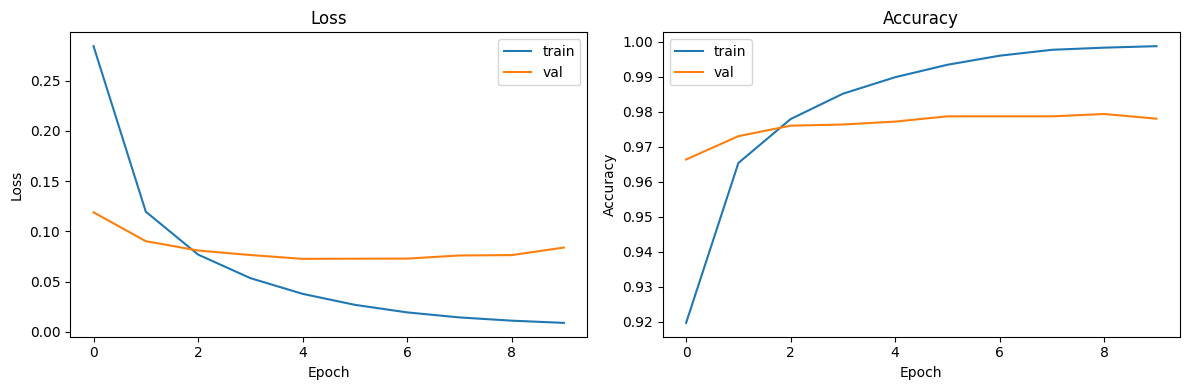

In [ ]:
tf.random.set_seed(42)

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(784,)),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.summary()
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(
    X_train_flat, training_labels,
    validation_split=0.1,
    epochs=10,
    batch_size=128,
    verbose=1
)

test_loss, test_acc = model.evaluate(X_test_flat, test_labels, verbose=1)
print(f"Test loss: {test_loss:.4f} | Test accuracy: {test_acc:.4f}")

plt.figure(figsize=(12,4))
plt.subplot(1,2,1); plt.plot(history.history['loss']); plt.plot(history.history['val_loss']);
plt.title('Loss'); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(['train','val'])
plt.subplot(1,2,2); plt.plot(history.history['accuracy']); plt.plot(history.history['val_accuracy']);
plt.title('Accuracy'); plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(['train','val'])
plt.tight_layout(); plt.show()

**Pregunta 3.2 (0.25 puntos)**: ¿crees conveniente utilizar una capa flatten en este caso? Motiva tu respuesta.



In [ ]:
### No código ###

**Respuesta a la pregunta 3.2**:

*No es necesario utilizar una capa Flatten, ya que el preprocesamiento previo ya transformó cada imagen de 28×28 píxeles en un vector unidimensional de 784 valores mediante reshape. La capa Flatten cumple precisamente esa función: convertir una matriz 2D (imagen) en un vector 1D para que las dense layers puedan procesarla. Como el modelo ya recibe los datos en ese formato incluir la capa Flatten sería redundante.*

**Pregunta 3.3 (0.25 puntos)**: Utiliza la función summary() para mostrar la estructura de tu modelo.

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,221,152 (4.66 MB)

 Trainable params: 407,050 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 814,102 (3.11 MB)

## 4: Compilación y entrenamiento

**Pregunta 4.1 (0.5 puntos)**: Compila tu modelo. Utiliza ***categorical_crossentropy*** como función de pérdida, ***Adam*** como optimizador, y monitoriza la ***tasa de acierto*** durante el entrenamiento. Explica qué hace cada cosa en la compilación.

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=['accuracy']
)

**Respuesta a la pregunta 4.1**:
*En la compilación del modelo se usó categorical_crossentropy como función de pérdida para medir la diferencia entre las predicciones y las etiquetas reales, el optimizador Adam para ajustar los pesos de forma eficiente durante el entrenamiento, y la métrica accuracy para evaluar el porcentaje de aciertos del modelo en cada epoch.*

**Pregunta 4.2 (0.5 puntos)**: Utiliza la función ***fit()*** para entrenar tu modelo. Para ayudarte en tu primer entrenamiento, utiliza estos valores:
*   epochs = 5
*   batch_size = 32
*   validation_split = 0.25



In [ ]:
history = model.fit(
    X_train_flat, training_labels,
    epochs=5,
    batch_size=32,
    validation_split=0.25,
    verbose=1
)

Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.9907 - loss: 0.0285 - val_accuracy: 0.9811 - val_loss: 0.0658
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.9934 - loss: 0.0201 - val_accuracy: 0.9819 - val_loss: 0.0648
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.9945 - loss: 0.0150 - val_accuracy: 0.9844 - val_loss: 0.0552
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.9958 - loss: 0.0127 - val_accuracy: 0.9797 - val_loss: 0.0779
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.9952 - loss: 0.0135 - val_accuracy: 0.9774 - val_loss: 0.0902


# 5: Impacto al variar el número de neuronas en las capas ocultas

En este ejercicio vamos a experimentar con nuestra red neuronal cambiando el numero de neuronas por 512 y por otros valores. Para ello, utiliza la red neuronal de la pregunta 3, y su capa oculta cambia el número de neuronas:

* **216 neuronas en la capa oculta
* **1024 neuronas en la capa oculta

y entrena la red en ambos casos.



In [ ]:
model_216 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(784,)),
    tf.keras.layers.Dense(216, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model_216.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history_216 = model_216.fit(
    X_train_flat, training_labels,
    epochs=5,
    batch_size=32,
    validation_split=0.25,
    verbose=1
)

Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8735 - loss: 0.4414 - val_accuracy: 0.9569 - val_loss: 0.1507
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.9648 - loss: 0.1185 - val_accuracy: 0.9655 - val_loss: 0.1168
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.9789 - loss: 0.0755 - val_accuracy: 0.9684 - val_loss: 0.1048
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9862 - loss: 0.0519 - val_accuracy: 0.9689 - val_loss: 0.1062
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9905 - loss: 0.0368 - val_accuracy: 0.9700 - val_loss: 0.1059


In [ ]:
model_1024 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(784,)),
    tf.keras.layers.Dense(1024, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model_1024.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history_1024 = model_1024.fit(
    X_train_flat, training_labels,
    epochs=5,
    batch_size=32,
    validation_split=0.25,
    verbose=1
)

Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 22s 15ms/step - accuracy: 0.8938 - loss: 0.3485 - val_accuracy: 0.9641 - val_loss: 0.1199
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 21s 15ms/step - accuracy: 0.9736 - loss: 0.0888 - val_accuracy: 0.9631 - val_loss: 0.1167
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 21s 15ms/step - accuracy: 0.9843 - loss: 0.0522 - val_accuracy: 0.9676 - val_loss: 0.1123
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 21s 15ms/step - accuracy: 0.9912 - loss: 0.0328 - val_accuracy: 0.9704 - val_loss: 0.1061
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 21s 15ms/step - accuracy: 0.9920 - loss: 0.0265 - val_accuracy: 0.9735 - val_loss: 0.1027


**Pregunta 5.1 (0.5 puntos)**: ¿Cual es el impacto que tiene la red neuronal?

Respuesta a la pregunta 5.1:
*Con 216 neuronas la red neuronal entrena más rápido y alcanza val_acc ≈ 0.9700, mostrando una menor capacidad pero buena generalización; con 1024 neuronas el tiempo casi se duplica y solo mejora levemente la val_acc ≈ 0.9735, mientras la train accuracy sube más, lo que sugiere mayor riesgo de sobreajuste. El aumento a 1024 no aporta un beneficio proporcional y el descenso a 216 pierde algo de precisión pero ahorra cómputo, se estima que una configuración de 512 neuronas ofrecería un mejor equilibrio.*

# 6: Número de neuronas de la capa de salida
Considerad la capa final, la de salida de la red neuronal de la pregunta 3.

**Pregunta 6.1 (0.25 puntos)**: ¿Por qué son 10 las neuronas de la última capa?

**Pregunta 6.2 (0.25 puntos)**: ¿Qué pasaría si tuvieras una cantidad diferente a 10?

Por ejemplo, intenta entrenar la red con 5, para ello utiliza la red neuronal de la pregunta 1 y cambia a 5 el número de neuronas en la última capa.

In [ ]:
y_train_raw10 = np.argmax(training_labels, axis=1)
y_test_raw10  = np.argmax(test_labels, axis=1)

y_train_raw5 = (y_train_raw10 % 5)
y_test_raw5  = (y_test_raw10 % 5)

y_train_5 = tf.keras.utils.to_categorical(y_train_raw5, num_classes=5)
y_test_5  = tf.keras.utils.to_categorical(y_test_raw5,  num_classes=5)

# Modelo: 784 -> Dense(512, relu) -> Dense(5, softmax)
model_5out = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(784,)),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(5, activation='softmax')
])

model_5out.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history_5out = model_5out.fit(
    X_train_flat, y_train_5,
    epochs=5,
    batch_size=32,
    validation_split=0.25,
    verbose=1
)

Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.9107 - loss: 0.2779 - val_accuracy: 0.9696 - val_loss: 0.0997
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9732 - loss: 0.0819 - val_accuracy: 0.9715 - val_loss: 0.0873
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.9846 - loss: 0.0492 - val_accuracy: 0.9760 - val_loss: 0.0787
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.9917 - loss: 0.0295 - val_accuracy: 0.9745 - val_loss: 0.0844
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.9945 - loss: 0.0200 - val_accuracy: 0.9749 - val_loss: 0.0887


Tu respuestas a la pregunta 6.1 aquí:
*Porque el problema es de 10 clases mutuamente excluyentes (dígitos 0–9); la última capa con 10 neuronas y softmax produce una distribución de probabilidad sobre esas diez clases y la pérdida categorical_crossentropy espera etiquetas one-hot de dimensión 10.*

Tu respuestas a la pregunta 6.2 aquí:
*Si se usa un número distinto de 10 sin cambiar las etiquetas, se tendrá una incompatibilidad de dimensiones (la salida del modelo no coincide con el tamaño del one-hot), y el entrenamiento fallará; si se ajustan las etiquetas a 5 clases se estará resolviendo un problema muy distinto al agrupar dígitos, por lo que ya no se podrá distinguir los 10 dígitos originales.*

# 7: Aumento de epoch y su efecto en la red neuronal
En este ejercicio vamos a ver el impacto de aumentar los epoch en el entrenamiento. Usando la red neuronal de la pregunta 3:

**Pregunta 7.1 (0.25 puntos)**
* Intentad 15 epoch para su entrenamiento, probablemente obtendras un modelo con una pérdida mucho mejor que el que tiene 5.

**Pregunta 7.2 (0.25 puntos)**
* Intenta ahora con 30 epoch para su entrenamiento.

**Pregunta 7.3 (0.25 puntos)**
* ¿Qué está pasando en la pregunta anterior? Explica tu respuesta y da el nombre de este efecto si lo conoces.

In [ ]:
history_15 = model.fit(
    X_train_flat, training_labels,
    epochs=15,
    batch_size=32,
    validation_split=0.25,
    verbose=1
)

Epoch 1/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.9972 - loss: 0.0095 - val_accuracy: 0.9831 - val_loss: 0.0691
Epoch 2/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.9958 - loss: 0.0132 - val_accuracy: 0.9813 - val_loss: 0.0815
Epoch 3/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.9959 - loss: 0.0117 - val_accuracy: 0.9845 - val_loss: 0.0708
Epoch 4/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.9978 - loss: 0.0070 - val_accuracy: 0.9815 - val_loss: 0.0867
Epoch 5/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.9975 - loss: 0.0078 - val_accuracy: 0.9817 - val_loss: 0.0853
Epoch 6/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - accuracy: 0.9971 - loss: 0.0091 - val_accuracy: 0.9817 - val_loss: 0.0816
Epoch 7/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - accuracy: 0.9971 - loss: 0.0095 - val_accuracy: 0.9800 - val_loss: 0.1001
Epoch 8/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.9975 - loss:

In [ ]:
history_30 = model.fit(
    X_train_flat, training_labels,
    epochs=30,
    batch_size=32,
    validation_split=0.25,
    verbose=1
)

Epoch 1/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.9984 - loss: 0.0044 - val_accuracy: 0.9823 - val_loss: 0.1167
Epoch 2/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.9991 - loss: 0.0032 - val_accuracy: 0.9753 - val_loss: 0.1639
Epoch 3/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - accuracy: 0.9976 - loss: 0.0072 - val_accuracy: 0.9813 - val_loss: 0.1309
Epoch 4/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.9984 - loss: 0.0048 - val_accuracy: 0.9790 - val_loss: 0.1442
Epoch 5/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.9981 - loss: 0.0060 - val_accuracy: 0.9809 - val_loss: 0.1300
Epoch 6/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.9984 - loss: 0.0060 - val_accuracy: 0.9803 - val_loss: 0.1401
Epoch 7/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.9984 - loss: 0.0055 - val_accuracy: 0.9809 - val_loss: 0.1404
Epoch 8/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.9990 - loss

Tu respuesta a la pregunta 7.3 aquí:
*Al aumentar los epochs, el modelo mejora el training (accuracy ≈ 0.999) pero la pérdida de validación sube y la val_accuracy oscila y luego cae lo cual es una señal de sobreajuste, lo que ignifica que la red neural memoriza mejor el conjunto de entrenamiento pero lo generaliza peor. Lo que se debería aplicar es utilizar early stopping.

# 8: Early stop
En el ejercicio anterior, cuando entrenabas con epoch extras, tenías un problema en el que tu pérdida podía cambiar. Puede que te haya llevado un poco de tiempo esperar a que el entrenamiento lo hiciera,  y puede que hayas pensado "¿no estaría bien si pudiera parar el entrenamiento cuando alcance un valor deseado?", es decir, una precisión del 85% podría ser suficiente para ti, y si alcanzas eso después de 3 epoch, ¿por qué sentarte a esperar a que termine muchas más épocas? Como cualquier otro programa existen formas de parar la ejecución

A partir del código de ejemplo, hacer una nueva función que tenga en cuenta la perdida (loss) y que pueda parar el código para evitar que ocurra el efeto secundario que vimos en el ejercicio 5.

In [ ]:
### Ejemplo de código

class myCallback(tf.keras.callbacks.Callback):
      def on_epoch_end(self, epoch, logs={}):
        if(logs.get('accuracy')> 0.85):
              print("\nAlcanzado el 85% de precisión, se cancela el entrenamiento!!")
              self.model.stop_training = True

**Pregunta 8.1. *(0.75 puntos)***: Consulta la documentación de Keras y aprende cómo podemos utilizar Early stop en nuestro modelos.

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, Callback

early_stop = EarlyStopping(
    monitor='val_loss',
    mode='min',
    patience=5,
    min_delta=1e-4,
    restore_best_weights=True,
    verbose=1
)

threshold_stop = LossThresholdStop(threshold=0.07, monitor='val_loss')

history_es = model.fit(
    X_train_flat, training_labels,
    epochs=50,                 # se cortará antes si no mejora o alcanza el umbral
    batch_size=32,
    validation_split=0.25,
    callbacks=[early_stop, threshold_stop],
    verbose=1
)

Epoch 1/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.9995 - loss: 0.0016 - val_accuracy: 0.9797 - val_loss: 0.2259
Epoch 2/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.9979 - loss: 0.0106 - val_accuracy: 0.9791 - val_loss: 0.2107
Epoch 3/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.9991 - loss: 0.0028 - val_accuracy: 0.9789 - val_loss: 0.2050
Epoch 4/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.9990 - loss: 0.0036 - val_accuracy: 0.9801 - val_loss: 0.2123
Epoch 5/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.9991 - loss: 0.0038 - val_accuracy: 0.9811 - val_loss: 0.1916
Epoch 6/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.9993 - loss: 0.0027 - val_accuracy: 0.9771 - val_loss: 0.2446
Epoch 7/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - accuracy: 0.9990 - loss: 0.0036 - val_accuracy: 0.9784 - val_loss: 0.2157
Epoch 8/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.9989 - loss: 

## 9. Unidades de activación

En este ejercicio, vamos a evaluar la importancia de utilizar las unidades de activación adecuadas. Como hemos visto en clase, funciones de activación como sigmoid han dejado de utilizarse en favor de otras unidades como ReLU.

**Pregunta 9.1 *(0.75 puntos)***: Utilizando la red realizada en el ejercicio 3, escribir un breve análisis comparando la utilización de unidades sigmoid y ReLU (por ejemplo, se pueden comentar aspectos como velocidad de convergencia, métricas obtenidas...). Explicar por qué pueden darse estas diferencias. Opcionalmente, comparar con otras activaciones disponibles en Keras.

*Pista: Usando redes más grandes se hace más sencillo apreciar las diferencias. Es mejor utilizar al menos 3 o 4 capas densas.*

*La activación Sigmoid transforma cada valor de entrada en un número entre 0 y 1, lo que permite interpretarlo como una probabilidad.*

In [ ]:
# Modelo con activación SIGMOID
model_sigmoid = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(784,)),
    tf.keras.layers.Dense(512, activation='sigmoid'),
    tf.keras.layers.Dense(256, activation='sigmoid'),
    tf.keras.layers.Dense(128, activation='sigmoid'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model_sigmoid.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history_sigmoid = model_sigmoid.fit(
    X_train_flat, training_labels,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)


Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - accuracy: 0.7075 - loss: 0.9683 - val_accuracy: 0.9346 - val_loss: 0.2228
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9369 - loss: 0.2110 - val_accuracy: 0.9531 - val_loss: 0.1553
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.9555 - loss: 0.1427 - val_accuracy: 0.9607 - val_loss: 0.1310
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.9692 - loss: 0.1028 - val_accuracy: 0.9672 - val_loss: 0.1114
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 21s 15ms/step - accuracy: 0.9772 - loss: 0.0769 - val_accuracy: 0.9711 - val_loss: 0.1027
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.9830 - loss: 0.0591 - val_accuracy: 0.9714 - val_loss: 0.1016
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9869 - loss: 0.0451 - val_accuracy: 0.9719 - val_loss: 0.1061
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.9905 - loss: 0.0346 - 

*La activación ReLU (Rectified Linear Unit) devuelve el valor de entrada si es positivo y cero en caso contrario.*

In [ ]:
# Modelo con activación RELU
model_relu = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(784,)),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model_relu.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history_relu = model_relu.fit(
    X_train_flat, training_labels,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.8764 - loss: 0.4054 - val_accuracy: 0.9593 - val_loss: 0.1310
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.9681 - loss: 0.0993 - val_accuracy: 0.9676 - val_loss: 0.1121
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.9798 - loss: 0.0619 - val_accuracy: 0.9664 - val_loss: 0.1193
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9862 - loss: 0.0446 - val_accuracy: 0.9718 - val_loss: 0.1099
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.9891 - loss: 0.0330 - val_accuracy: 0.9708 - val_loss: 0.1256
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.9898 - loss: 0.0315 - val_accuracy: 0.9738 - val_loss: 0.1181
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.9919 - loss: 0.0258 - val_accuracy: 0.9707 - val_loss: 0.1170
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.9905 - loss: 0.0280 - 

*Sigmoid y ReLU rindieron prácticamente igual, ambas alcanzaron un val_accuracy de aproximadamente 0.977 y un val_loss de aproximadamente 0.09–0.10 en 10 epochs. En general, ReLU suele converger más rápido y escalar mejor en redes neuronales más profundas, pero en nuestra configuración la diferencia no se aprecia. En casos donde la profundidad sea de 3–4 dense layers, y al entrenar más epochs ReLU suele mantener mejor la convergencia que sigmoid.*

## 10. Inicialización de parámetros

En este ejercicio, vamos a evaluar la importancia de una correcta inicialización de parámetros en una red neuronal.

**Pregunta 10.1 *(0.75 puntos)***: Partiendo de una red similar a la del ejercicio anterior (usando ya ReLUs), comentar las diferencias que se aprecian en el entrenamiento al utilizar distintas estrategias de inicialización de parámetros. Para ello, inicializar todas las capas con las siguientes estrategias, disponibles en Keras, y analizar sus diferencias:

* Inicialización con ceros.
* Inicialización con una variable aleatoria normal.
* Inicialización con los valores por defecto de Keras para una capa Dense (estrategia *glorot uniform*)

In [ ]:
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras import Sequential
from tensorflow.keras.initializers import Zeros, RandomNormal, GlorotUniform

tf.random.set_seed(42)

def build_model(initializer):
    return Sequential([
        Input(shape=(784,)),
        Dense(512, activation='relu', kernel_initializer=initializer),
        Dense(256, activation='relu', kernel_initializer=initializer),
        Dense(128, activation='relu', kernel_initializer=initializer),
        Dense(10,  activation='softmax', kernel_initializer=initializer),
    ])

def train_and_report(name, initializer, epochs=8, batch_size=64):
    model = build_model(initializer)
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    hist = model.fit(
        X_train_flat, training_labels,
        epochs=epochs, batch_size=batch_size,
        validation_split=0.2, verbose=1
    )
    print(f"\n{name} -> last acc: {hist.history['accuracy'][-1]:.4f}, "
          f"last val_acc: {hist.history['val_accuracy'][-1]:.4f}, "
          f"last loss: {hist.history['loss'][-1]:.4f}, "
          f"last val_loss: {hist.history['val_loss'][-1]:.4f}")
    return hist

hist_zeros = train_and_report("Zeros", Zeros())
hist_norm  = train_and_report("RandomNormal", RandomNormal(mean=0.0, stddev=0.05, seed=42))
hist_glorot= train_and_report("GlorotUniform (default)", GlorotUniform(seed=42))

Epoch 1/8
750/750 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.1154 - loss: 2.3018 - val_accuracy: 0.1060 - val_loss: 2.3020
Epoch 2/8
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.1159 - loss: 2.3008 - val_accuracy: 0.1060 - val_loss: 2.3020
Epoch 3/8
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.1159 - loss: 2.3008 - val_accuracy: 0.1060 - val_loss: 2.3021
Epoch 4/8
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.1159 - loss: 2.3007 - val_accuracy: 0.1060 - val_loss: 2.3021
Epoch 5/8
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.1159 - loss: 2.3007 - val_accuracy: 0.1060 - val_loss: 2.3021
Epoch 6/8
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.1159 - loss: 2.3007 - val_accuracy: 0.1060 - val_loss: 2.3021
Epoch 7/8
750/750 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - accuracy: 0.1159 - loss: 2.3007 - val_accuracy: 0.1060 - val_loss: 2.3021
Epoch 8/8
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.1159 - loss: 2.3007 - val_accu

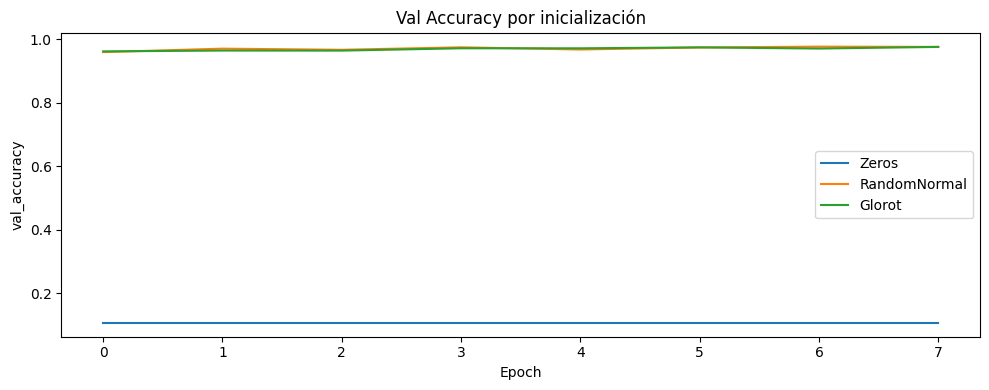

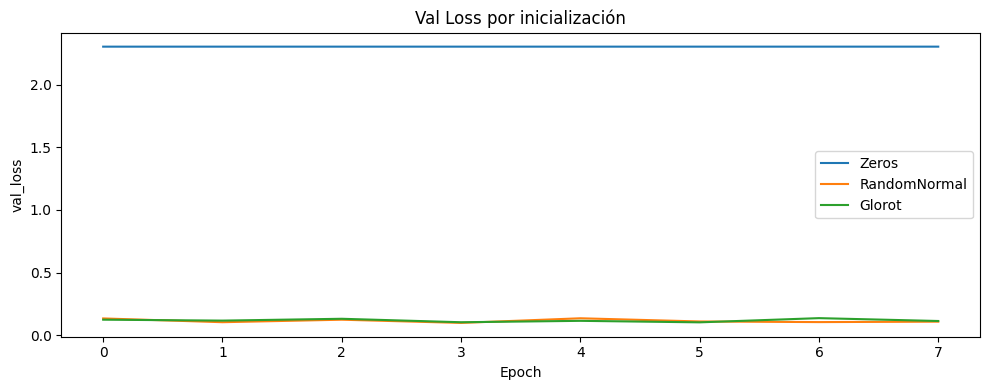

In [ ]:
def plot_histories(hdict, key, title):
    plt.figure(figsize=(10,4))
    for name, h in hdict.items():
        plt.plot(h.history[key], label=name)
    plt.title(title); plt.xlabel('Epoch'); plt.ylabel(key); plt.legend(); plt.tight_layout(); plt.show()

plot_histories({"Zeros":hist_zeros, "RandomNormal":hist_norm, "Glorot":hist_glorot}, "val_accuracy", "Val Accuracy por inicialización")
plot_histories({"Zeros":hist_zeros, "RandomNormal":hist_norm, "Glorot":hist_glorot}, "val_loss", "Val Loss por inicialización")

*Con el uso de ceros, la red neural no aprende, llega a obtener un accuracy de aproximadamente 0.116 y un val_accuracy de aproximadamente 0.106, es decir la simetría inicial impide que las neuronas se entrenen adecuadamente. Con RandomNormal y con GlorotUniform, el entrenamiento progresa bien y ambos alcanzan métricas muy similares un val_accuracy de aproximadamente 0.976 y un val_loss de aproximadamente 0.10, con ligeras oscilaciones de val_loss. Por lo tanto, inicializar en ceros no es recomendabe; Glorot y Normal funcionan de forma estable con ReLU.*

## 11. Optimizadores

**Problema 11.1 *(0.75 puntos)***: Partiendo de una red similar a la del ejercicio anterior (utilizando la mejor estrategia de inicialización observada), comparar y analizar las diferencias que se observan  al entrenar con varios de los optimizadores vistos en clase, incluyendo SGD como optimizador básico (se puede explorar el espacio de hiperparámetros de cada optimizador, aunque para optimizadores más avanzados del estilo de RMSprop es buena idea dejar los valores por defecto provistos por Keras).

In [ ]:
tf.random.set_seed(42)

def build_model(optimizer):
    model = Sequential([
        Input(shape=(784,)),
        Dense(512, activation='relu', kernel_initializer=GlorotUniform()),
        Dense(256, activation='relu', kernel_initializer=GlorotUniform()),
        Dense(128, activation='relu', kernel_initializer=GlorotUniform()),
        Dense(10, activation='softmax', kernel_initializer=GlorotUniform())
    ])
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
    return model

optimizers = {
    "SGD": tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.0),
    "SGD + momentum": tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    "RMSprop": tf.keras.optimizers.RMSprop(),
    "Adam": tf.keras.optimizers.Adam(),
}

histories = {}
for name, opt in optimizers.items():
    print(f"\nEntrenando con {name}...")
    model = build_model(opt)
    hist = model.fit(
        X_train_flat, training_labels,
        epochs=8, batch_size=64, validation_split=0.2, verbose=1
    )
    acc, val_acc = hist.history["accuracy"][-1], hist.history["val_accuracy"][-1]
    print(f"{name} -> acc: {acc:.4f} | val_acc: {val_acc:.4f}")
    histories[name] = hist


Entrenando con SGD...
Epoch 1/8
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.6567 - loss: 1.3564 - val_accuracy: 0.9008 - val_loss: 0.3606
Epoch 2/8
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.9006 - loss: 0.3565 - val_accuracy: 0.9202 - val_loss: 0.2787
Epoch 3/8
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9197 - loss: 0.2838 - val_accuracy: 0.9311 - val_loss: 0.2411
Epoch 4/8
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9300 - loss: 0.2440 - val_accuracy: 0.9390 - val_loss: 0.2154
Epoch 5/8
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.9380 - loss: 0.2148 - val_accuracy: 0.9448 - val_loss: 0.1957
Epoch 6/8
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.9437 - loss: 0.1914 - val_accuracy: 0.9500 - val_loss: 0.1797
Epoch 7/8
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9492 - loss: 0.1720 - val_accuracy: 0.9529 - val_loss: 0.1667
Epoch 8/8
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.9542 - loss: 0.15

*Usanfo SGD, la red aprende correctamente pero de forma más lenta y con precisión moderada alcanzando un val_acc de aproximadamente 0.95. Al añadir momentum, la convergencia mejora notablemente y se alcanzan val_acc de aproximadamente 0.97 a 0.98. RMSprop acelera el aprendizaje adaptando la tasa por parámetro, manteniendo una precisión estable de val_acc de aproximadamente 0.975 aunque con ligera variabilidad en la pérdida. Finalmente, Adam logra resultados similares en validación con un val_acc de aproximadamente 0.975 pero con una convergencia más rápida y estable, combinando momentum y adaptación de tasa. En resumen: SGD < SGD + momentum < RMSprop y Adam, siendo Adam el más eficiente y equilibrado para este escenario.*

## 12. Regularización y red final *(1.25 puntos)*

**Problema 12.1 *(2 puntos)***: Entrenar una red final que sea capaz de obtener una accuracy en el validation superior al 95%. Para ello, combinar todo lo aprendido anteriormente y utilizar técnicas de regularización para evitar overfitting. Algunos de los elementos que pueden tenerse en cuenta son los siguientes.

* Número de capas y neuronas por capa
* Optimizadores y sus parámetros
* Batch size
* Unidades de activación
* Uso de capas dropout, regularización L2, regularización L1...
* Early stopping (se puede aplicar como un callback de Keras, o se puede ver un poco "a ojo" cuándo el modelo empieza a caer en overfitting y seleccionar el número de epochs necesarias)
* Batch normalization

Si los modelos entrenados anteriormente ya se acercaban al valor requerido de accuracy, probar distintas estrategias igualmente y comentar los resultados.

Explicar brevemente la estrategia seguida y los modelos probados para obtener el modelo final, que debe verse entrenado en este Notebook. No es necesario guardar el entrenamiento de todos los modelos que se han probado, es suficiente con explicar cómo se ha llegado al modelo final.

In [ ]:
#Importaciones y configuración

from tensorflow.keras.layers import Input, Dense, BatchNormalization, Dropout, Activation
from tensorflow.keras.initializers import HeNormal
from tensorflow.keras.regularizers import l2

tf.random.set_seed(42)

In [ ]:
#Definición del modelo
model_final = Sequential([
    Input(shape=(784,)),
    Dense(512, kernel_initializer=HeNormal(), kernel_regularizer=l2(1e-4)),
    BatchNormalization(), Activation('relu'), Dropout(0.30),

    Dense(256, kernel_initializer=HeNormal(), kernel_regularizer=l2(1e-4)),
    BatchNormalization(), Activation('relu'), Dropout(0.30),

    Dense(128, kernel_initializer=HeNormal(), kernel_regularizer=l2(5e-5)),
    BatchNormalization(), Activation('relu'), Dropout(0.20),

    Dense(10, activation='softmax')
])

In [ ]:
#Compilación del modelo

model_final.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
#Callbacks: EarlyStopping y ReduceLROnPlateau

es = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', mode='min', patience=8, restore_best_weights=True, verbose=1
)

rlrop = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', mode='min', factor=0.5, patience=3, min_lr=1e-5, verbose=1
)

In [ ]:
#Entrenamiento

history_final = model_final.fit(
    X_train_flat, training_labels,
    epochs=50,
    batch_size=64,
    validation_split=0.20,
    callbacks=[es, rlrop],
    verbose=1
)

Epoch 1/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 17s 19ms/step - accuracy: 0.8222 - loss: 0.7224 - val_accuracy: 0.9611 - val_loss: 0.2577 - learning_rate: 0.0010
Epoch 2/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - accuracy: 0.9435 - loss: 0.3137 - val_accuracy: 0.9715 - val_loss: 0.2194 - learning_rate: 0.0010
Epoch 3/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.9578 - loss: 0.2605 - val_accuracy: 0.9732 - val_loss: 0.2060 - learning_rate: 0.0010
Epoch 4/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 21s 18ms/step - accuracy: 0.9633 - loss: 0.2367 - val_accuracy: 0.9762 - val_loss: 0.1973 - learning_rate: 0.0010
Epoch 5/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.9685 - loss: 0.2188 - val_accuracy: 0.9758 - val_loss: 0.1985 - learning_rate: 0.0010
Epoch 6/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.9708 - loss: 0.2045 - val_accuracy: 0.9760 - val_loss: 0.1951 - learning_rate: 0.0010
Epoch 7/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - accuracy: 0.9725 - l

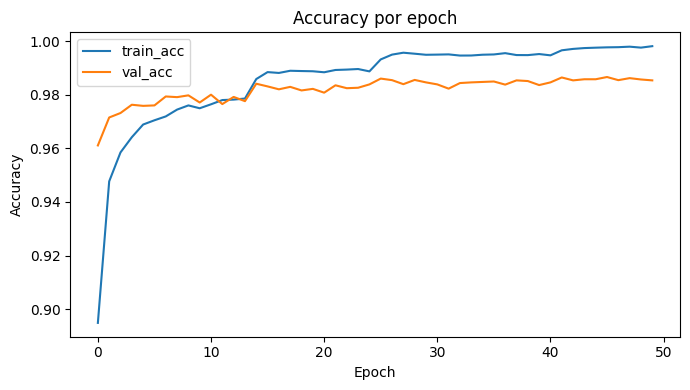

In [ ]:
#Gráfica de accuracy

plt.figure(figsize=(7,4))
plt.plot(history_final.history['accuracy'], label='train_acc')
plt.plot(history_final.history['val_accuracy'], label='val_acc')
plt.title('Accuracy por epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
#Evaluación en test

test_loss, test_acc = model_final.evaluate(X_test_flat, test_labels, verbose=0)
print(f"Test loss: {test_loss:.4f} | Test accuracy: {test_acc:.4f}")

Test loss: 0.1027 | Test accuracy: 0.9858


In [ ]:
#Predicciones y matriz de confusión

y_prob = model_final.predict(X_test_flat, verbose=0)
y_pred = np.argmax(y_prob, axis=1)
y_true = np.argmax(test_labels, axis=1)

acc_manual = (y_pred == y_true).mean()
cm = tf.math.confusion_matrix(y_true, y_pred, num_classes=10).numpy()

print(f"Accuracy (predict/argmax): {acc_manual:.4f}")
print("Confusion matrix:\n", cm)

Accuracy (predict/argmax): 0.9858
Confusion matrix:
 [[ 971    1    1    0    0    0    5    1    1    0]
 [   0 1128    1    0    0    0    2    1    3    0]
 [   0    1 1022    2    1    0    1    4    1    0]
 [   0    0    4  986    0    8    0    5    2    5]
 [   1    0    0    0  963    0    5    0    2   11]
 [   2    0    0    4    0  878    3    2    1    2]
 [   2    2    1    0    3    2  948    0    0    0]
 [   1    1    9    0    0    0    0 1014    1    2]
 [   2    0    2    3    3    1    1    3  958    1]
 [   2    2    0    3    6    0    1    4    1  990]]


*Se usó una MLP (Multilayer Perceptron) con ReLU + HeNormal, tres bloques Dense→BatchNorm→Dropout (512/256/128 con Dropout 0.30/0.30/0.20 y L2=1e-4/1e-4/5e-5) para controlar overfitting, optimizada con Adam (lr=1e-3), ReduceLROnPlateau (reducciones en epochs 14, 25 y 41) y EarlyStopping con restore_best_weights. Con un batch_size=64 y val_split=0.2, la red neural estabilizó la val_accuracy en aproximadamente 0.9866 (mejor epoch 46–49) y obtuvo un Test acc de 0.9858, confirmando una buena generalización. En conjunto, la combinación BN + Dropout + L2 + LR scheduling permitió superar el 95% de val_acc solicitado.*